In [25]:
import pandas as pd
import numpy as np
import re
import pickle

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [51]:
from sklearn.preprocessing import LabelEncoder

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
social_media = pd.read_csv('social_media_2024.csv')

In [54]:
social_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              3000 non-null   object 
 1   original_text     3000 non-null   object 
 2   url               3000 non-null   object 
 3   author_hash       1988 non-null   object 
 4   language          3000 non-null   object 
 5   primary_theme     2988 non-null   object 
 6   english_keywords  2954 non-null   object 
 7   sentiment         3000 non-null   float64
 8   main_emotion      3000 non-null   object 
 9   secondary_themes  3000 non-null   object 
dtypes: float64(1), object(9)
memory usage: 234.5+ KB


In [55]:
social_media.describe()

,sentiment
count,3000.000000
mean,0.094352
std,0.420004
min,-0.940000
25%,-0.190000
50%,0.110000
75%,0.402500
max,0.960000


In [56]:
social_media.head(3)

,date,original_text,url,author_hash,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes
0,2024-12-01T00:00:00.000Z,Ｑ:\n銀杏並木からラグビー場東門に通じる港区の区道の廃止手続きはいつを予定していますか？\...,https://x.com/L6K6REOaiF71115/status/186301012...,619fca2174ff02b246aae19903b1cf5d55be82b9,ja,Politics,"namiki, area, gate, east, harbor, framework, p...",-0.23,neutral,"[3, 11, 7]"
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,https://x.com/RT_com/status/1863010120734568538,bc410c3cdef579aef084ee58828626a1c40e0e19,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,"[3, 11, 7]"
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,https://x.com/KindlyBfan/status/18630101211456...,2f77c6eabf92d58b777497c4fda819cbe411263d,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,"[9, 3, 7]"


In [57]:
social_media = social_media.drop(columns=['url','author_hash']) 

In [58]:
social_media = social_media[social_media['language'] == 'en']

In [59]:
theme = LabelEncoder()           
social_media['primary_theme_num'] = theme.fit_transform(social_media['primary_theme']) 

In [60]:
emotion = LabelEncoder()            
social_media['main_emotion_num'] = emotion.fit_transform(social_media['main_emotion']) 

In [61]:
social_media.columns

Index(['date', 'original_text', 'language', 'primary_theme',
       'english_keywords', 'sentiment', 'main_emotion', 'secondary_themes',
       'primary_theme_num', 'main_emotion_num'],
      dtype='object')

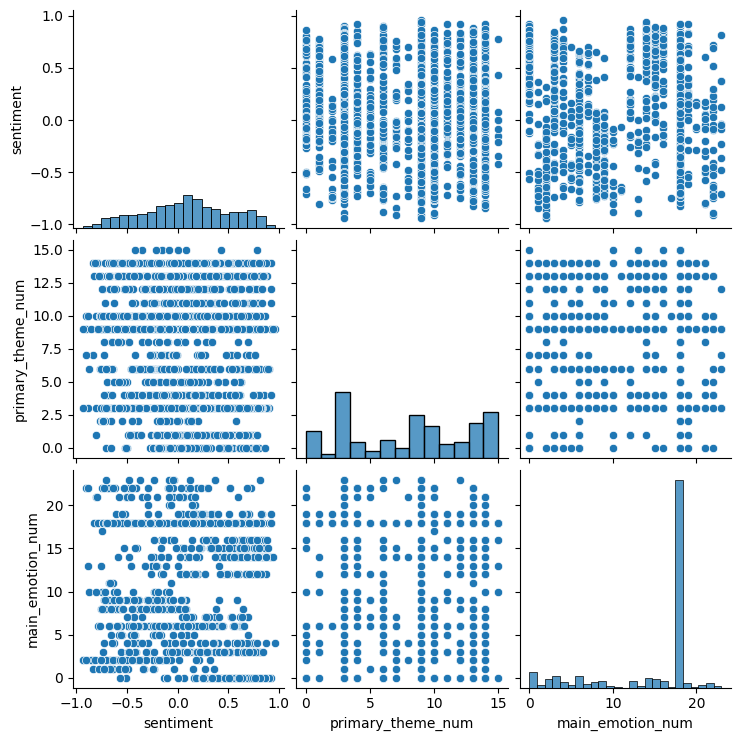

In [62]:
sns.pairplot(social_media);

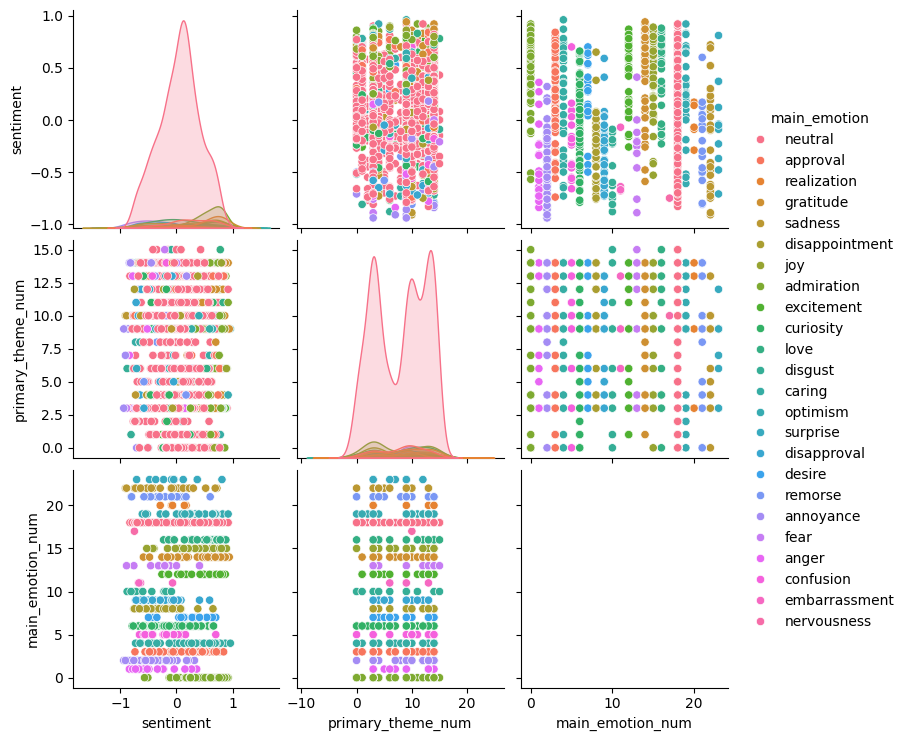

In [63]:
sns.pairplot(social_media,hue='main_emotion');

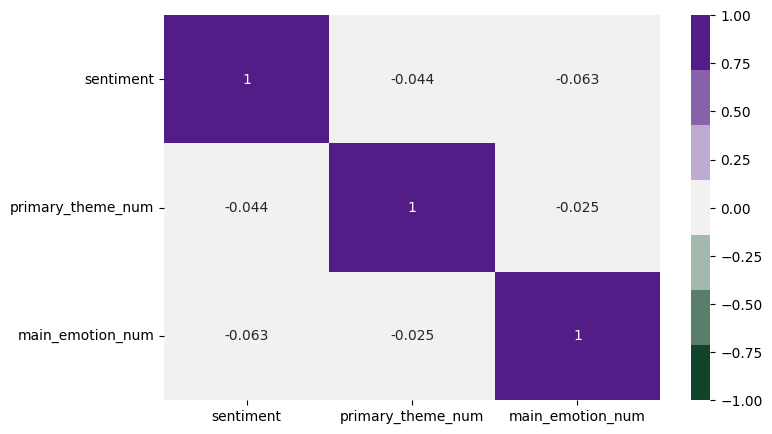

In [64]:
plt.figure(figsize=(8,5))
sns.heatmap(social_media.corr(numeric_only=True),
           vmin=-1,
           vmax=1,
           cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
           annot=True);

In [65]:
social_media['original_text'].head()

1    Russian Defense Minister Andrey Belousov laid ...
2     Life isn't a choice it's a duty.  \n@KindlyMyers
4    ![gif](giphy|BkfAhfmX0Ppn2)\n\nFall in line pe...
5       BLACK OPS 6 🔥 #CallofDuty #CallofDutyBlackOps6
6    I accidentally wore all black. One of the cool...
Name: original_text, dtype: object

In [66]:
import re
signos = re.compile(r"(\.)|(\;)|(\:)|(\!)|(\?)|(\¿)|(\@)|(\,)|(\")|(\()|(\))|(\[)|(\])|(\d+)|(//)|(-)|(\$)|(€)")

In [67]:
def signs_tweets(descripcion):
    return signos.sub('', descripcion.lower())

social_media['original_text_processed'] = social_media['original_text'].apply(signs_tweets)
social_media['original_text_processed'].head()

1    russian defense minister andrey belousov laid ...
2       life isn't a choice it's a duty  \nkindlymyers
4          gifgiphy|bkfahfmxppn\n\nfall in line people
5         black ops  🔥 #callofduty #callofdutyblackops
6    i accidentally wore all black one of the cool ...
Name: original_text_processed, dtype: object

In [68]:
def remove_links(social_media):
    return " ".join(['{link}' if ('http') in word else word for word in social_media.split()])

social_media['original_text_processed'] = social_media['original_text'].apply(remove_links)

In [69]:
import nltk

In [70]:
nltk.download('stopwords', download_dir='C:/Users/infoa/nltk_data')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:/Users/infoa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [71]:
english_stopwords = stopwords.words('english')

NameError: name 'stopwords' is not defined

In [ ]:
def remove_stopwords(social_media):
    return " ".join([word for word in social_media.split() if word not in english_stopwords])

In [ ]:
social_media['original_text_processed'] = social_media['original_text'].apply(remove_stopwords)
social_media.head()

,date,original_text,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes,primary_theme_num,main_emotion_num,original_text_processed
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,"[3, 11, 7]",10,18,Russian Defense Minister Andrey Belousov laid ...
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,"[9, 3, 7]",1,3,Life choice duty. @KindlyMyers
4,2024-12-01T00:00:00.000Z,![gif](giphy|BkfAhfmX0Ppn2)\n\nFall in line pe...,en,Technology,"line, line people, people, giphy, fall, gif",-0.04,neutral,"[1, 3, 7]",14,18,![gif](giphy|BkfAhfmX0Ppn2) Fall line people
5,2024-12-01T00:00:00.000Z,BLACK OPS 6 🔥 #CallofDuty #CallofDutyBlackOps6,en,Technology,"black, OPS, BLACK OPS, callofdutyblackops6, op...",-0.06,neutral,"[3, 7]",14,18,BLACK OPS 6 🔥 #CallofDuty #CallofDutyBlackOps6
6,2024-12-01T00:00:00.000Z,I accidentally wore all black. One of the cool...,en,Entertainment,"accidentally, cool, accidentally wore, wore, k...",0.17,realization,"[3, 14, 7]",3,20,I accidentally wore black. One cool kids


In [ ]:
from nltk.stem.snowball import SnowballStemmer

def english_stemmer(x):
    stemmer = SnowballStemmer('english')
    return " ".join([stemmer.stem(word) for word in x.split()])

social_media['original_text_processed'] = social_media['original_text'].apply(english_stemmer)
social_media['original_text_processed'].head()

1    russian defens minist andrey belousov laid flo...
2              life isn't a choic it a duty. @kindlymy
4       ![gif](giphy|bkfahfmx0ppn2) fall in line peopl
5        black op 6 🔥 #callofduti #callofdutyblackops6
6       i accident wore all black. one of the cool kid
Name: original_text_processed, dtype: object

In [ ]:
social_media['original_text_processed'].head()

1    russian defens minist andrey belousov laid flo...
2              life isn't a choic it a duty. @kindlymy
4       ![gif](giphy|bkfahfmx0ppn2) fall in line peopl
5        black op 6 🔥 #callofduti #callofdutyblackops6
6       i accident wore all black. one of the cool kid
Name: original_text_processed, dtype: object

In [ ]:
def map_sentiment(val):
    if val in [1, 2]:
        return "Negativo"
    elif val == 3:
        return "Neutro"
    else:
        return "Positivo"

social_media['sentiment_label'] = social_media['sentiment'].apply(map_sentiment)

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r"\d+", '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [ ]:
social_media['original_text_processed'] = social_media['original_text_processed'].astype(str).apply(clean_text)

In [ ]:
social_media.head(3)

,date,original_text,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes,primary_theme_num,main_emotion_num,original_text_processed,sentiment_label
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,"[3, 11, 7]",10,18,russian defens minist andrey belousov laid flo...,Positivo
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,"[9, 3, 7]",1,3,life isnt a choic it a duty,Positivo
4,2024-12-01T00:00:00.000Z,![gif](giphy|BkfAhfmX0Ppn2)\n\nFall in line pe...,en,Technology,"line, line people, people, giphy, fall, gif",-0.04,neutral,"[1, 3, 7]",14,18,gifgiphybkfahfmxppn fall in line peopl,Positivo


In [ ]:
print(social_media['original_text_processed'].dtype)


object


In [ ]:
social_media.columns

Index(['date', 'original_text', 'language', 'primary_theme',
       'english_keywords', 'sentiment', 'main_emotion', 'secondary_themes',
       'primary_theme_num', 'main_emotion_num', 'original_text_processed',
       'sentiment_label'],
      dtype='object')

In [ ]:
X = social_media['original_text_processed']
y = social_media['sentiment_label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
vectorizer = CountVectorizer(binary=True)
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [ ]:
print(X_train_vect.shape)
print(len(y_train))

(1669, 9427)
1669


In [ ]:
corpus = social_media['original_text_processed']

In [ ]:
vectorizer = CountVectorizer(binary=True)
X = vectorizer.fit_transform(corpus)
vectorizer.get_feature_names_out()

array(['_____________________________', 'aaaaaaaa', 'aamus', ...,
       '𝙈𝙊𝙍𝙉𝙄𝙉𝙂', '𝙍𝙀𝙈𝙄𝙉𝘿𝙀𝙍', '𝙏𝙪𝙣𝙚'], shape=(9732,), dtype=object)

In [ ]:
len(vectorizer.get_feature_names_out())

9732

In [ ]:
df_final = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

NameError: name 'X' is not defined

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
reviews_train_clean = X_train
reviews_test_clean = X_test

In [ ]:
# Si aparece una palabra en una review, le pone un 1. Da igual que aparezca 100 veces, no cuenta. Xq binary=True
# Solo pone 1s cuando detecta una palabra en una review
baseline_vectorizer = CountVectorizer(binary=True)
baseline_vectorizer.fit(reviews_train_clean)

# Reviews en formato vector de palabras. El mismo vectorizador a test, tiene que mantener la estructura
X_baseline = baseline_vectorizer.transform(reviews_train_clean)
X_test_baseline = baseline_vectorizer.transform(reviews_test_clean)

In [ ]:
X_baseline

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 34733 stored elements and shape (1669, 8598)>

In [ ]:
print(X_baseline.shape)

# Asigna un numero según el orden de aparicion
baseline_vectorizer.vocabulary_

(1669, 8598)


{'capit': 1149,
 'commodifi': 1523,
 'everyth': 2544,
 'nature': 4946,
 'labor': 4106,
 'and': 309,
 'even': 2531,
 'life': 4251,
 'can': 1123,
 'disco': 2112,
 'disrupt': 2141,
 'this': 7581,
 'cycl': 1837,
 'creat': 1747,
 'more': 4826,
 'human': 3543,
 'future': 2979,
 'commodif': 1522,
 'altern': 259,
 'socialgood': 6974,
 'dealt': 1917,
 'with': 8351,
 'kidney': 4040,
 'stone': 7194,
 'onc': 5265,
 'back': 586,
 'in': 3649,
 'one': 5270,
 'thing': 7573,
 'that': 7541,
 'dont': 2204,
 'want': 8175,
 'to': 7653,
 'experi': 2596,
 'again': 141,
 'know': 4074,
 'week': 8240,
 'has': 3334,
 'been': 697,
 'slow': 6922,
 'due': 2276,
 'nasti': 4938,
 'cold': 1476,
 'got': 3148,
 'just': 3972,
 'befor': 699,
 'thanksgiving': 7540,
 'defens': 1959,
 'fuck': 2957,
 'suck': 7286,
 'man': 4461,
 'smh': 6944,
 'final': 2769,
 'when': 8284,
 'we': 8218,
 'need': 4971,
 'it': 3846,
 'the': 7544,
 'most': 4838,
 'cannabi': 1141,
 'use': 7991,
 'caus': 1210,
 'chromosom': 1356,
 'damage': 1856,
 '

In [ ]:
vectorizer_c = CountVectorizer()
vectorizer_c.fit(reviews_train_clean)

# Ya no es binaria la aparicion, sino un conteo por palabra
X_baseline_c = vectorizer_c.transform(reviews_train_clean)

In [ ]:
print(X_baseline_c.shape)
print(len(vectorizer_c.get_feature_names_out())) # Las mismas
# X_baseline_c.toarray()

(1669, 8598)
8598


In [ ]:
# Matriz demasiado grande como para que numpy la imprima por pantalla
X_baseline_c

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 34733 stored elements and shape (1669, 8598)>

In [ ]:
social_media.head(3)

,date,original_text,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes,primary_theme_num,main_emotion_num,original_text_processed,sentiment_label
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,"[3, 11, 7]",10,18,russian defens minist andrey belousov laid flo...,Positivo
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,"[9, 3, 7]",1,3,life isnt a choic it a duty,Positivo
4,2024-12-01T00:00:00.000Z,![gif](giphy|BkfAhfmX0Ppn2)\n\nFall in line pe...,en,Technology,"line, line people, people, giphy, fall, gif",-0.04,neutral,"[1, 3, 7]",14,18,gifgiphybkfahfmxppn fall in line peopl,Positivo
